In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mariosameh12/datasets121/DeepX_train.xlsx
/kaggle/input/datasets/mariosameh12/datasets121/DeepX_validation.xlsx
/kaggle/input/datasets/mariosameh12/datasets121/DeepX_unlabeled.xlsx
/kaggle/input/datasets/mariosameh12/hidden/DeepX_hidden_test (3).xlsx


In [1]:
!pip install emoji langdetect openpyxl -q

print("✅ Libraries installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 39.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Libraries installed


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import f1_score
from tqdm import tqdm
import json
import re
import random
import os
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
# ============= COMPLETE FIXED ULTRA TRANSLATOR =============

class FrancoUltraTranslator:
    """FIXED Ultra-Complex Franco-Arabic Translator"""
    
    def __init__(self):
        # ============================================================
        # LAYER 1: PHONETIC NUMBER MAPPING
        # ============================================================
        self.number_map_primary = {
            '2': 'ا', '2a': 'ا', '2e': 'ا', '2o': 'ا',
            '3': 'ع', '3a': 'ع', '3e': 'ع', '3o': 'ع',
            '7': 'ح', '7a': 'ح', '7e': 'ح', '7o': 'ح',
            '8': 'غ', '8a': 'غ', '8e': 'غ', '8o': 'غ',
            '9': 'ص', '9a': 'ص', '9e': 'ص', '9o': 'ص',
            '6': 'ط', '6a': 'ط', '6e': 'ط', '6o': 'ط',
            '5': 'خ', '5a': 'خ', '5e': 'خ', '5o': 'خ',
            '4': 'ش', '4a': 'ش', '4e': 'ش', '4o': 'ش',
            "'": 'ء',
        }
        
        self.combinations = {
            'sh': 'ش', 'ch': 'تش', 'th': 'ث', 'kh': 'خ',
            'gh': 'غ', 'dh': 'ذ', 'zh': 'ظ',
            'aa': 'ا', 'ee': 'ي', 'oo': 'و', 'uu': 'و', 'ii': 'ي',
            'ei': 'ي', 'ai': 'ي', 'ou': 'و', 'au': 'و',
        }
        
        self.letter_map = {
            'a': 'ا', 'b': 'ب', 't': 'ت', 'j': 'ج', 'h': 'ح',
            'd': 'د', 'r': 'ر', 'z': 'ز', 's': 'س', 'f': 'ف',
            'q': 'ق', 'k': 'ك', 'l': 'ل', 'm': 'م', 'n': 'ن',
            'w': 'و', 'y': 'ي', 'e': 'ع', 'g': 'ج',
            'p': 'ب', 'v': 'ف', 'c': 'ك',
        }
        
        self.arabic_normalization = {
            'إ': 'ا', 'أ': 'ا', 'آ': 'ا', 'ى': 'ا', 'ة': 'ه',
            'ؤ': 'ء', 'ئ': 'ء',
        }
        
        # ============================================================
        # LAYER 2: COMPREHENSIVE DICTIONARY (UPDATED)
        # ============================================================
        self.dictionary = {
            # Pronouns
            'ana': 'انا', 'enta': 'انت', 'enti': 'انتي', 'ento': 'انتو',
            'ehna': 'احنا', 'homma': 'هما', 'hoa': 'هو', 'heya': 'هي',
            
            # Service related
            '5idma': 'خدمة', '5edma': 'خدمة', 'khidma': 'خدمة', 'khedma': 'خدمة',
            'service': 'خدمة',
            
            # Quality words
            '7elwa': 'حلوة', '7elw': 'حلو', 'helwa': 'حلوة', 'helw': 'حلو',
            'gedan': 'جداً', 'gdn': 'جداً', 'gd': 'جداً',
            'ktir': 'كتير', 'kteer': 'كتير',
            'awi': 'اوي', 'awy': 'اوي',
            
            # Religious/Common phrases
            'el 7amd lelah': 'الحمد لله',
            'el7amd lelah': 'الحمد لله',
            '7amd lelah': 'الحمد لله',
            'alhamdulillah': 'الحمد لله',
            'wallahi': 'والله',
            'walahi': 'والله',
            
            # Completion words
            'khales': 'خالص', 'khalis': 'خالص',
            
            # Action words
            '2a5er 7aga': 'اخر حاجة', '2a5er': 'اخر',
            '7aga': 'حاجة', '7agat': 'حاجات',
            
            # Intensifiers
            'mofraza': 'مفرزة', 'mofraza awi': 'مفرزة اوي',
            'mofraza awi!': 'مفرزة اوي!',
            
            # Articles
            'el': 'ال', 'al': 'ال', 'il': 'ال',
            
            # Common words
            'kwayes': 'كويس', 'kwyes': 'كويس', 'kways': 'كويس',
            'mish': 'مش', 'mesh': 'مش', 'mosh': 'مش',
            '3ayez': 'عايز', '3ayza': 'عايزة', '3ayzin': 'عايزين',
            '7abibi': 'حبيبي', 'shukran': 'شكرا', 'khalas': 'خلاص',
            'tamam': 'تمام', 'mumtaz': 'ممتاز',
            'wa7esh': 'وحش', 'baaed': 'بايت', 'baared': 'بارد',
            'ghaly': 'غالي', 'ro3a': 'روعة',
            
            # Prepositions
            'fi': 'في', '3ala': 'على', 'min': 'من', 'ila': 'الى',
            'maa': 'مع', 'bdoon': 'بدون',
            
            # Conjunctions
            'w': 'و', 'aw': 'او', 'bas': 'بس', 'la2no': 'لأنه',
            
            # Question words
            'eeh': 'ايه', 'leeh': 'ليه', 'fein': 'فين',
            'emta': 'امتى', 'kam': 'كام', 'ezzay': 'ازاي',
            'taman': 'تمن', 'sa3r': 'سعر',
            
            # Time
            'bokra': 'بكرا', 'embareh': 'امبارح',
            'dilwa2ti': 'دلوقتي', 'hal2et': 'حالقت',
            
            # Actions
            'ro7t': 'روحت', 'kalt': 'كلت', 'talabt': 'طلبت',
            'wasalni': 'وصلني',
        }
        
        # Sorting dictionary
        self.dictionary = dict(sorted(self.dictionary.items(), key=lambda x: -len(x[0])))
        
        # ============================================================
        # LAYER 3: SPELLING CORRECTIONS
        # ============================================================
        self.spelling_corrections = {
            '5dma': '5idma', '5edma': '5idma',
            '7lwa': '7elwa', '7lw': '7elw',
            'gdan': 'gedan', 'gdn': 'gedan',
            'kewayes': 'kwayes', 'kwaiyes': 'kwayes',
            '3ayz': '3ayez', '3ayzah': '3ayza',
            'tamem': 'tamam', 'tmam': 'tamam',
            'mosh': 'mesh', 'mich': 'mesh',
        }
    
    def detect_dialect(self, text: str):
        """Simple dialect detection"""
        return 'egyptian'
    
    def detect_context(self, text: str):
        """Simple context detection"""
        text_lower = text.lower()
        if any(w in text_lower for w in ['akl', 'food', 'mat3am', 't3m']):
            return 'restaurant'
        return 'general'
    
    def transliterate(self, text: str, dialect=None, context=None) -> str:
        """Main transliteration function"""
        if not isinstance(text, str):
            return text
        
        text = text.lower()
        
        # Step 1: Spelling correction
        for wrong, correct in self.spelling_corrections.items():
            text = re.sub(r'\b' + re.escape(wrong) + r'\b', correct, text)
        
        # Step 2: Dictionary replacement (longest first)
        for franco, arabic in self.dictionary.items():
            pattern = r'\b' + re.escape(franco) + r'\b'
            text = re.sub(pattern, arabic, text)
        
        # Step 3: Number mapping
        for num, arabic in self.number_map_primary.items():
            text = text.replace(num, arabic)
        
        # Step 4: Letter combinations
        for combo, arabic in self.combinations.items():
            text = text.replace(combo, arabic)
        
        # Step 5: Handle remaining Latin letters
        words = text.split()
        converted_words = []
        
        for word in words:
            if any(c.isalpha() and c.isascii() for c in word) and len(word) < 15:
                converted = ''
                i = 0
                while i < len(word):
                    if i < len(word) - 1 and word[i:i+2] in self.combinations:
                        converted += self.combinations[word[i:i+2]]
                        i += 2
                    else:
                        converted += self.letter_map.get(word[i], word[i])
                        i += 1
                converted_words.append(converted)
            else:
                converted_words.append(word)
        
        text = ' '.join(converted_words)
        
        # Step 6: Normalize Arabic
        for before, after in self.arabic_normalization.items():
            text = text.replace(before, after)
        
        # Step 7: Clean up
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def translate_with_metadata(self, text: str) -> dict:
        """Return translation with metadata"""
        return {
            'original': text,
            'translated': self.transliterate(text),
            'detected_dialect': self.detect_dialect(text),
            'detected_context': self.detect_context(text),
        }

# ============= ADD THIS ALIAS =============
# This creates an alias so the UltimateTextPreprocessor can find the class
FrancoArabicTranslator = FrancoUltraTranslator

print("✅ FIXED Ultra-Complex Franco Translator ready!")

# Quick test
translator = FrancoUltraTranslator()
test = "el 5idma 7elwa gedan"
result = translator.transliterate(test)
print(f"\nTest: {test}")
print(f"Result: {result}")
print(f"Expected: الخدمة حلوة جدا")

✅ FIXED Ultra-Complex Franco Translator ready!

Test: el 5idma 7elwa gedan
Result: ال خدمه حلوه جداً
Expected: الخدمة حلوة جدا


In [5]:
# ============= NEW CELL 4.5: Egyptian Slang Handler =============

class EgyptianSlangHandler:
    """Handle Egyptian dialect and slang"""
    
    def __init__(self):
        # Egyptian slang to sentiment mapping
        self.slang_sentiment = {
            # Positive slang
            'تحفة': 'positive', 'تحفه': 'positive', 'تحفففه': 'positive',
            'جامد': 'positive', 'جامده': 'positive', 'خيال': 'positive',
            'خرافي': 'positive', 'عظمة': 'positive', 'عظمه': 'positive',
            'زي الفل': 'positive', 'زي القمر': 'positive',
            'فل': 'positive', 'مبروك': 'positive', 'ربنا يخليك': 'positive',
            'نعمة': 'positive', 'حلو اوي': 'positive', 'جميل اوي': 'positive',
            
            # Negative slang
            'بايظ': 'negative', 'بايز': 'negative', 'بوظ': 'negative',
            'وحش': 'negative', 'وحشة': 'negative', 'وحشه': 'negative',
            'زبالة': 'negative', 'زباله': 'negative', 'قرف': 'negative',
            'مقرف': 'negative', 'وسخ': 'negative', 'وسخة': 'negative',
            'فاشل': 'negative', 'فاشلة': 'negative', 'تحت السلم': 'negative',
            'نص كم': 'negative', 'حرامي': 'negative', 'حرامية': 'negative',
            'نصب': 'negative', 'نصاب': 'negative', 'خايس': 'negative',
            
            # Neutral slang
            'عادي': 'neutral', 'عادي أوي': 'neutral', 'نص نص': 'neutral',
            'مش واو': 'neutral', 'مش وااو': 'neutral', 'ماشي الحال': 'neutral',
            'مقبول': 'neutral', 'يعني يعني': 'neutral', 'مش بطال': 'neutral',
            
            # Intensifiers
            'اوي': 'intensifier', 'قوي': 'intensifier', 'جداً': 'intensifier',
            'خالص': 'intensifier', 'بتاع': 'intensifier',
        }
        
        # Dialectal word variants to standard
        self.dialect_map = {
            'عاوز': 'عايز', 'عاوزة': 'عايزة', 'عاوزين': 'عايزين',
            'عايز': 'عايز', 'عايزة': 'عايزة', 'عايزين': 'عايزين',
            'أكل': 'اكل', 'أكلة': 'اكلة',
            'حاجة': 'حاجة', 'حاجه': 'حاجة',
            'نضيف': 'نظيف', 'نضيفة': 'نظيفة',
            'شاطر': 'شاطر', 'شاطرة': 'شاطرة',
            'ممتاز': 'ممتاز', 'ممتازة': 'ممتازة',
            'جميل': 'جميل', 'جميلة': 'جميلة',
        }
    
    def process(self, text):
        """Process Egyptian slang in text"""
        if not isinstance(text, str):
            return text, {}
        
        original_text = text
        sentiment_hints = {'positive': 0, 'negative': 0, 'neutral': 0}
        
        # Check for slang words
        text_lower = text.lower()
        
        for slang, sentiment in self.slang_sentiment.items():
            if slang in text_lower:
                if sentiment in ['positive', 'negative', 'neutral']:
                    sentiment_hints[sentiment] += 1
        
        # Apply dialect normalization
        for dialect, standard in self.dialect_map.items():
            text = text.replace(dialect, standard)
        
        return text, sentiment_hints
    
    def get_dominant_sentiment(self, sentiment_hints):
        """Get dominant sentiment from hints"""
        if sentiment_hints['positive'] > sentiment_hints['negative']:
            return 'positive'
        elif sentiment_hints['negative'] > sentiment_hints['positive']:
            return 'negative'
        else:
            return 'neutral'

print("✅ Egyptian Slang Handler ready")

✅ Egyptian Slang Handler ready


In [6]:
# ============= NEW CELL 4.6: Multilingual Handler =============

class MultilingualHandler:
    """Handle multiple languages in reviews"""
    
    def __init__(self):
        # Language-specific sentiment lexicons
        self.sentiment_lexicons = {
            'en': {
                'positive': ['good', 'great', 'excellent', 'amazing', 'perfect', 'love', 'best', 'awesome', 'fantastic', 'wonderful'],
                'negative': ['bad', 'poor', 'terrible', 'awful', 'worst', 'hate', 'disappointing', 'horrible', 'useless', 'waste'],
                'neutral': ['okay', 'fine', 'average', 'normal', 'decent', 'acceptable']
            },
            'fr': {
                'positive': ['bon', 'bien', 'excellent', 'super', 'génial', 'parfait', 'formidable', 'magnifique'],
                'negative': ['mauvais', 'mal', 'terrible', 'horrible', 'décevant', 'nul', 'nulle'],
                'neutral': ['correct', 'passable', 'moyen', 'acceptable']
            },
            'it': {
                'positive': ['buono', 'ottimo', 'eccellente', 'perfetto', 'grandioso', 'magnifico'],
                'negative': ['cattivo', 'pessimo', 'terribile', 'orribile', 'deludente'],
                'neutral': ['normale', 'accettabile', 'discreto']
            },
            'de': {
                'positive': ['gut', 'großartig', 'ausgezeichnet', 'perfekt', 'wunderbar', 'fantastisch'],
                'negative': ['schlecht', 'schlimm', 'furchtbar', 'entsetzlich', 'enttäuschend'],
                'neutral': ['akzeptabel', 'durchschnittlich', 'normal']
            },
            'tr': {
                'positive': ['iyi', 'harika', 'mükemmel', 'süper', 'güzel', 'şaheser'],
                'negative': ['kötü', 'berbat', 'rezalet', 'iğrenç', 'hayal kırıklığı'],
                'neutral': ['normal', 'ortalama', 'kabul edilebilir']
            }
        }
        
        # Language detection patterns
        self.lang_patterns = {
            'fr': r'[àâéèêëîïôùûçœ]',
            'de': r'[äöüß]',
            'tr': r'[ğüşöçİı]',
            'it': r'[àèéìòù]',
        }
    
    def detect_language(self, text):
        """Detect language of text"""
        if not isinstance(text, str):
            return 'unknown'
        
        text_lower = text.lower()
        
        # Check for language-specific characters
        for lang, pattern in self.lang_patterns.items():
            if re.search(pattern, text_lower):
                return lang
        
        # Check for Arabic script
        if any('\u0600' <= c <= '\u06FF' for c in text):
            return 'ar'
        
        # Default to English for Latin script
        if any(c.isalpha() and c.isascii() for c in text):
            return 'en'
        
        return 'unknown'
    
    def extract_sentiment_from_foreign(self, text, lang):
        """Extract sentiment hints from foreign language text"""
        if lang not in self.sentiment_lexicons:
            return {'positive': 0, 'negative': 0, 'neutral': 0}
        
        text_lower = text.lower()
        lexicon = self.sentiment_lexicons[lang]
        hints = {'positive': 0, 'negative': 0, 'neutral': 0}
        
        for word in lexicon['positive']:
            if word in text_lower:
                hints['positive'] += 1
        for word in lexicon['negative']:
            if word in text_lower:
                hints['negative'] += 1
        for word in lexicon['neutral']:
            if word in text_lower:
                hints['neutral'] += 1
        
        return hints
    
    def translate_key_phrases(self, text, lang):
        """Translate key phrases from foreign languages to Arabic"""
        translations = {
            'en': {
                'good': 'جيد', 'very good': 'جيد جدا', 'excellent': 'ممتاز',
                'bad': 'سيء', 'very bad': 'سيء جدا', 'terrible': 'فظيع',
                'service': 'الخدمة', 'food': 'الاكل', 'price': 'السعر',
                'delivery': 'التوصيل', 'quality': 'الجودة'
            },
            'fr': {
                'bon': 'جيد', 'très bon': 'جيد جدا', 'excellent': 'ممتاز',
                'mauvais': 'سيء', 'service': 'الخدمة', 'prix': 'السعر',
                'livraison': 'التوصيل', 'qualité': 'الجودة'
            },
            'it': {
                'buono': 'جيد', 'ottimo': 'ممتاز', 'cattivo': 'سيء',
                'servizio': 'الخدمة', 'prezzo': 'السعر'
            },
            'de': {
                'gut': 'جيد', 'ausgezeichnet': 'ممتاز', 'schlecht': 'سيء',
                'service': 'الخدمة', 'preis': 'السعر'
            },
            'tr': {
                'iyi': 'جيد', 'harika': 'ممتاز', 'kötü': 'سيء',
                'hizmet': 'الخدمة', 'fiyat': 'السعر'
            }
        }
        
        if lang in translations:
            text_lower = text.lower()
            for foreign, arabic in translations[lang].items():
                if foreign in text_lower:
                    text = text.replace(foreign, arabic)
        
        return text

print("✅ Multilingual Handler ready")

✅ Multilingual Handler ready


In [7]:
class EmojiProcessor:
    """Convert emojis to text descriptions"""
    
    def __init__(self):
        self.emoji_map = {
            '❤️': ' love ', '❤': ' love ', '💙': ' love ', '💚': ' love ',
            '💛': ' love ', '🧡': ' love ', '💜': ' love ', '🩷': ' love ',
            '😍': ' love ', '🥰': ' love ', '😘': ' kiss ', '💋': ' kiss ',
            '👍': ' good ', '👌': ' good ', '💪': ' strong ', '🔥': ' amazing ',
            '😊': ' happy ', '😄': ' happy ', '😁': ' happy ', '😃': ' happy ',
            '😂': ' funny ', '🤣': ' funny ', '😹': ' funny ',
            '😡': ' angry ', '😠': ' angry ', '🤬': ' angry ', '👎': ' bad ',
            '💔': ' sad ', '😢': ' sad ', '😭': ' sad ', '😞': ' sad ',
            '🎉': ' celebration ', '🎊': ' celebration ', '🥳': ' celebration ',
            '✨': ' sparkle ', '⭐': ' star ', '🌟': ' star ',
            '💯': ' perfect ', '‼️': ' important ', '❗': ' important ',
        }
    
    def process(self, text):
        """Convert emojis to text descriptions"""
        if not isinstance(text, str):
            return text
        
        for emj, word in self.emoji_map.items():
            text = text.replace(emj, word)
        
        # Remove any remaining emojis
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"
            u"\U0001F300-\U0001F5FF"
            u"\U0001F680-\U0001F6FF"
            u"\U0001F1E0-\U0001F1FF"
            u"\U00002702-\U000027B0"
            u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r' ', text)
        
        return text

print("✅ Emoji Processor ready")

✅ Emoji Processor ready


In [8]:
# ============= CELL 6: FINAL FIXED UltimateTextPreprocessor =============

class UltimateTextPreprocessor:
    """Complete preprocessor with Franco, Slang, and Multilingual support"""
    
    def __init__(self):
        self.franco = FrancoArabicTranslator()
        self.slang = EgyptianSlangHandler()
        self.multilingual = MultilingualHandler()
        
        # Simple emoji removal
        self.emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"
            u"\U0001F300-\U0001F5FF"
            u"\U0001F680-\U0001F6FF"
            u"\U0001F1E0-\U0001F1FF"
        "]+", flags=re.UNICODE)
        
        self.arabic_normalization = {
            'إ': 'ا', 'أ': 'ا', 'آ': 'ا', 'ى': 'ا', 'ة': 'ه',
            'ؤ': 'ء', 'ئ': 'ء',
        }
        
        # Franco indicators - ONLY these trigger conversion
        self.franco_numbers = ['2', '3', '7', '8', '9', '6', '5', '4']
        self.franco_words = ['ana', 'enta', 'enti', 'kwayes', 'kwyes', 'mish', 'mesh', 
                            '3ayez', '3ayza', '7abibi', 'y3ni', 'khalas', 'awi', 'awy',
                            'shukran', 'wallahi', 'helw', 'baheb', 'gedan', 'ktir']
    
    def remove_emojis(self, text):
        """Remove emojis from text"""
        return self.emoji_pattern.sub(r' ', text)
    
    def is_franco(self, text):
        """Strict Franco detection - ONLY convert if clearly Franco-Arabic"""
        if not isinstance(text, str) or len(text) < 3:
            return False
        
        # CRITICAL: If text has Arabic script, it's NOT Franco
        if any('\u0600' <= c <= '\u06FF' for c in text):
            return False
        
        text_lower = text.lower()
        
        # Check for Franco numbers (strongest indicator)
        has_franco_numbers = any(num in text for num in self.franco_numbers)
        
        # Check for common Franco dialect words
        has_franco_word = any(word in text_lower.split() for word in self.franco_words)
        
        # Check for Arabic-like consonant clusters (e.g., "kwayes" has pattern)
        # But only if text is short and has no spaces (likely a single word)
        words = text_lower.split()
        if len(words) == 1 and len(text) < 15:
            # Check for patterns like consonant-vowel-consonant-vowel-consonant
            has_arabic_pattern = text_lower.count('a') > 1 and text_lower.count('e') > 0
            return has_franco_numbers or has_franco_word or has_arabic_pattern
        
        # For multi-word text, require numbers OR multiple Franco words
        if len(words) > 1:
            franco_word_count = sum(1 for w in words if w in self.franco_words)
            return has_franco_numbers or franco_word_count >= 2
        
        return has_franco_numbers or has_franco_word
    
    def clean_text(self, text):
        """Ultimate text cleaning with all enhancements"""
        if pd.isna(text) or not isinstance(text, str):
            return ""
        
        original_text = text
        
        # Step 1: Detect language
        lang = self.multilingual.detect_language(text)
        
        # Step 2: Check if this is Franco-Arabic that needs conversion
        is_franco_text = self.is_franco(text)
        
        # Step 3: For English/French/etc., keep original - NO conversion
        if lang in ['en', 'fr', 'it', 'de', 'tr'] and not is_franco_text:
            # Just clean special characters and keep original
            text = self.remove_emojis(text)
            text = re.sub(r'[^\w\s\.\?\!]', ' ', text)
            text = re.sub(r'\s+', ' ', text).strip()
            self.last_lang = lang
            self.last_slang_hints = {}
            self.was_franco = False
            return text
        
        # Step 4: Convert Franco to Arabic (only if clearly Franco)
        if is_franco_text:
            text = self.franco.transliterate(text)
            lang = 'ar'  # After conversion, treat as Arabic
        
        # Step 5: Process Egyptian slang (for Arabic text)
        slang_hints = {}
        if lang == 'ar' or any('\u0600' <= c <= '\u06FF' for c in text):
            text, slang_hints = self.slang.process(text)
        
        # Step 6: Remove emojis
        text = self.remove_emojis(text)
        
        # Step 7: Normalize Arabic characters
        for before, after in self.arabic_normalization.items():
            text = text.replace(before, after)
        
        # Step 8: Remove diacritics
        text = re.sub(r'[\u064B-\u0652]', '', text)
        
        # Step 9: Remove elongation
        text = re.sub(r'(.)\1{2,}', r'\1', text)
        
        # Step 10: Clean special characters
        text = re.sub(r'[^\w\s\u0600-\u06FF\.\?\!]', ' ', text)
        
        # Step 11: Normalize spaces
        text = re.sub(r'\s+', ' ', text).strip()
        
        # Store metadata
        self.last_lang = lang
        self.last_slang_hints = slang_hints
        self.was_franco = is_franco_text
        
        return text

print("✅ FINAL FIXED UltimateTextPreprocessor ready!")

✅ FINAL FIXED UltimateTextPreprocessor ready!


In [9]:
class FrancoABSADataset(Dataset):
    """Dataset with Franco-Arabic support AND star ratings"""
    
    def __init__(self, df, tokenizer, preprocessor, max_length=128, is_training=True):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.preprocessor = preprocessor
        self.is_training = is_training
        self.records = []
        
        # Find text column
        self.text_col = None
        for col in ['review_text', 'text', 'review', 'comment']:
            if col in df.columns:
                self.text_col = col
                break
        if self.text_col is None:
            self.text_col = df.columns[0]
        
        # Find star rating column
        self.star_col = None
        for col in ['star_rating', 'rating', 'stars', 'rate']:
            if col in df.columns:
                self.star_col = col
                break
        
        print(f"Using text column: {self.text_col}")
        if self.star_col:
            print(f"✅ Using star rating column: {self.star_col}")
        else:
            print(f"⚠️ No star rating column found - using text only")
        
        # Aspect taxonomy
        self.aspects = ["food", "service", "price", "cleanliness",
                       "delivery", "ambiance", "app_experience", "general", "none"]
        self.aspect_to_idx = {a: i for i, a in enumerate(self.aspects)}
        self.sentiments = ["positive", "negative", "neutral"]
        self.sentiment_to_idx = {s: i for i, s in enumerate(self.sentiments)}
        
        for idx, row in df.iterrows():
            text = str(row[self.text_col]) if pd.notna(row[self.text_col]) else ""
            text = self.preprocessor.clean_text(text)
            
            if len(text) < 3:
                continue
            
            # Get star rating (normalized to 0-1 range)
            star_rating = 0.0
            if self.star_col and pd.notna(row[self.star_col]):
                try:
                    rating = float(row[self.star_col])
                    # Normalize 1-5 stars to 0-1 range
                    star_rating = (rating - 1) / 4
                except:
                    star_rating = 0.0
            
            aspect_labels = np.zeros(len(self.aspects), dtype=np.float32)
            sentiment_labels = np.full(len(self.aspects), -1, dtype=np.int64)
            
            if is_training and 'aspects' in df.columns:
                try:
                    aspects = row['aspects']
                    if isinstance(aspects, str):
                        aspects = json.loads(aspects)
                    
                    sents = row['aspect_sentiments']
                    if isinstance(sents, str):
                        sents = json.loads(sents)
                    
                    for asp in aspects:
                        if asp in self.aspect_to_idx:
                            a_idx = self.aspect_to_idx[asp]
                            aspect_labels[a_idx] = 1.0
                            sent = sents.get(asp, "neutral")
                            sentiment_labels[a_idx] = self.sentiment_to_idx.get(sent, 2)
                except:
                    pass
            
            self.records.append({
                'text': text,
                'star_rating': star_rating,
                'aspect_labels': aspect_labels,
                'sentiment_labels': sentiment_labels
            })
        
        print(f"Loaded {len(self.records)} samples")
    
    def __len__(self):
        return len(self.records)
    
    def __getitem__(self, idx):
        rec = self.records[idx]
        encoding = self.tokenizer(
            rec['text'],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'star_rating': torch.tensor(rec['star_rating'], dtype=torch.float),
            'aspect_labels': torch.tensor(rec['aspect_labels'], dtype=torch.float),
            'sentiment_labels': torch.tensor(rec['sentiment_labels'], dtype=torch.long),
        }

print("✅ Dataset class with star ratings ready!")

✅ Dataset class with star ratings ready!


In [24]:
class FrancoABSAModel(nn.Module):
    """Enhanced model with Franco-Arabic support AND star ratings"""
    
    def __init__(self, model_name="xlm-roberta-base", dropout=0.1, num_aspects=9, num_sentiments=3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        self.num_aspects = num_aspects
        self.num_sentiments = num_sentiments
        
        self.dropout = nn.Dropout(dropout)
        
        # Text encoder outputs
        self.aspect_head = nn.Linear(hidden_size, num_aspects)
        self.sentiment_head = nn.Linear(hidden_size, num_aspects * num_sentiments)
        
        # Star rating embedding and fusion
        self.star_embedding = nn.Linear(1, 64)
        self.star_norm = nn.LayerNorm(64)
        
        # Fusion layer to combine text and star features
        self.fusion_layer = nn.Linear(hidden_size + 64, hidden_size)
        self.fusion_norm = nn.LayerNorm(hidden_size)
        
    def forward(self, input_ids, attention_mask, star_rating):
        # Text encoding
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]  # [batch, hidden_size] - 2D
        pooled = self.dropout(pooled)
        
        # Star rating encoding
        # star_rating comes as [batch] or [batch, 1]
        if star_rating.dim() == 1:
            star_rating = star_rating.unsqueeze(1)  # [batch, 1]
        
        star_features = self.star_embedding(star_rating)  # [batch, 64]
        star_features = self.star_norm(star_features)    # [batch, 64]
        
        # Fuse text and star features - both are 2D now
        combined = torch.cat([pooled, star_features], dim=1)  # [batch, hidden_size + 64]
        fused = self.fusion_layer(combined)                   # [batch, hidden_size]
        fused = self.fusion_norm(fused)                       # [batch, hidden_size]
        fused = self.dropout(fused)
        
        # Aspect and sentiment predictions
        aspect_logits = self.aspect_head(fused)               # [batch, num_aspects]
        sentiment_logits = self.sentiment_head(fused).view(-1, self.num_aspects, self.num_sentiments)
        
        return aspect_logits, sentiment_logits

print("✅ Model class with star ratings ready!")

✅ Model class with star ratings ready!


In [11]:
def compute_loss(aspect_logits, sentiment_logits, aspect_labels, sentiment_labels):
    """Compute combined loss"""
    pos_weight = torch.tensor([3.0, 1.0, 2.0, 4.0, 4.0, 2.5, 2.0, 3.0, 8.0],
                               device=aspect_logits.device)
    aspect_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(aspect_logits, aspect_labels)
    
    mask = sentiment_labels >= 0
    if mask.sum() == 0:
        return aspect_loss
    
    sentiment_logits_flat = sentiment_logits.view(-1, 3)
    sentiment_labels_flat = sentiment_labels.view(-1)
    mask_flat = mask.view(-1)
    
    class_weights = torch.tensor([1.0, 1.0, 4.0], device=sentiment_logits.device)
    sentiment_loss = nn.CrossEntropyLoss(weight=class_weights)(
        sentiment_logits_flat[mask_flat],
        sentiment_labels_flat[mask_flat]
    )
    
    return aspect_loss + sentiment_loss

def evaluate(model, loader, device, threshold=0.5):
    """Evaluate model WITH STAR RATINGS support"""
    model.eval()
    all_true_pairs, all_pred_pairs = [], []
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            star_rating = batch["star_rating"].to(device)  # ← ADD THIS LINE
            aspect_labels = batch["aspect_labels"].cpu().numpy()
            sentiment_labels = batch["sentiment_labels"].cpu().numpy()
            
            # Pass star_rating to model
            aspect_logits, sentiment_logits = model(input_ids, attention_mask, star_rating)  # ← MODIFIED
            aspect_probs = torch.sigmoid(aspect_logits).cpu().numpy()
            sentiment_preds = sentiment_logits.argmax(-1).cpu().numpy()
            
            B = aspect_probs.shape[0]
            A = aspect_probs.shape[1]
            
            for b in range(B):
                true_pairs, pred_pairs = [], []
                for a in range(A):
                    if aspect_labels[b, a] == 1:
                        true_pairs.append((a, sentiment_labels[b, a]))
                    if aspect_probs[b, a] >= threshold:
                        pred_pairs.append((a, sentiment_preds[b, a]))
                
                all_true_pairs.append(set(true_pairs))
                all_pred_pairs.append(set(pred_pairs))
    
    tp = sum(len(true & pred) for true, pred in zip(all_true_pairs, all_pred_pairs))
    fp = sum(len(pred - true) for true, pred in zip(all_true_pairs, all_pred_pairs))
    fn = sum(len(true - pred) for true, pred in zip(all_true_pairs, all_pred_pairs))
    
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    
    return f1, precision, recall

print("✅ Loss and evaluation functions ready with star ratings support!")

✅ Loss and evaluation functions ready with star ratings support!


In [12]:
# Load your files
TRAIN_FILE = "/kaggle/input/datasets/mariosameh12/datasets121/DeepX_train.xlsx"
VAL_FILE = "/kaggle/input/datasets/mariosameh12/datasets121/DeepX_validation.xlsx"
TEST_FILE = "/kaggle/input/datasets/mariosameh12/hidden/DeepX_hidden_test (3).xlsx"

print("Loading data...")
train_df = pd.read_excel(TRAIN_FILE, engine='openpyxl')
val_df = pd.read_excel(VAL_FILE, engine='openpyxl')
test_df = pd.read_excel(TEST_FILE, engine='openpyxl')

print(f"Train: {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")
print(f"\nColumns: {train_df.columns.tolist()}")

# Show sample
print("\nSample from training data:")
print(train_df.iloc[0].to_dict())

Loading data...
Train: 1971 samples
Validation: 500 samples
Test: 500 samples

Columns: ['review_id', 'review_text', 'star_rating', 'date', 'business_name', 'business_category', 'platform', 'aspects', 'aspect_sentiments']

Sample from training data:
{'review_id': 7238, 'review_text': 'لا يوجد الدفع بالبطاقه عند الاستلام', 'star_rating': 3, 'date': datetime.datetime(2026, 3, 8, 0, 0), 'business_name': 'Noon', 'business_category': 'ecommerce', 'platform': 'play_store', 'aspects': '["app_experience", "delivery"]', 'aspect_sentiments': '{"app_experience": "negative", "delivery": "negative"}'}


In [13]:
# ============= TEST WITH DIRECT INSTANCE =============

# Initialize the Franco translator directly (NOT UltimateTextPreprocessor)
translator = FrancoUltraTranslator()

test_franco_samples = [
    "ana 3ayez akl kwayes",
    "shukran 7abibi",
    "el 7amd lelah",
    "mish kwayes khales",
    "y3ni keda 2a5er 7aga",
    "el 5idma 7elwa gedan",
    "kam el taman? de mofraza awi!",
    "wallahi el akl kan helw",
]

print("="*60)
print("ULTRA-COMPLEX FRANCO-ARABIC CONVERSION TEST")
print("="*60)

for franco in test_franco_samples:
    # Direct transliteration using FrancoUltraTranslator
    converted = translator.transliterate(franco)
    
    print(f"\n📝 Franco:     {franco}")
    print(f"🔄 Converted:  {converted}")
    
    # Get metadata
    metadata = translator.translate_with_metadata(franco)
    print(f"🗣️ Dialect:    {metadata['detected_dialect']}")
    print(f"📂 Context:    {metadata['detected_context']}")
    
    # Quality check
    has_arabic = any('\u0600' <= c <= '\u06FF' for c in converted)
    print(f"✅ Status:     {'Success' if has_arabic else 'Needs improvement'}")

print("\n" + "="*60)
print("✅ Test complete!")

ULTRA-COMPLEX FRANCO-ARABIC CONVERSION TEST

📝 Franco:     ana 3ayez akl kwayes
🔄 Converted:  انا عايز اكل كويس
🗣️ Dialect:    egyptian
📂 Context:    restaurant
✅ Status:     Success

📝 Franco:     shukran 7abibi
🔄 Converted:  شكرا حبيبي
🗣️ Dialect:    egyptian
📂 Context:    general
✅ Status:     Success

📝 Franco:     el 7amd lelah
🔄 Converted:  الحمد لله
🗣️ Dialect:    egyptian
📂 Context:    general
✅ Status:     Success

📝 Franco:     mish kwayes khales
🔄 Converted:  مش كويس خالص
🗣️ Dialect:    egyptian
📂 Context:    general
✅ Status:     Success

📝 Franco:     y3ni keda 2a5er 7aga
🔄 Converted:  يعنi كعدا اخر حاجه
🗣️ Dialect:    egyptian
📂 Context:    general
✅ Status:     Success

📝 Franco:     el 5idma 7elwa gedan
🔄 Converted:  ال خدمه حلوه جداً
🗣️ Dialect:    egyptian
📂 Context:    general
✅ Status:     Success

📝 Franco:     kam el taman? de mofraza awi!
🔄 Converted:  كام ال تمن? دع مفرزه اوي!
🗣️ Dialect:    egyptian
📂 Context:    general
✅ Status:     Success

📝 Franco:     wal

In [14]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load tokenizer and model
MODEL_NAME = "xlm-roberta-base"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = FrancoABSAModel(MODEL_NAME, dropout=0.1).to(device)

print(f"✅ Model loaded")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Loading xlm-roberta-base...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded
   Parameters: 278,712,868


In [15]:
# Initialize preprocessor
preprocessor = UltimateTextPreprocessor()


# Create datasets
print("Creating datasets...")
train_dataset = FrancoABSADataset(train_df, tokenizer, preprocessor, max_length=128, is_training=True)
val_dataset = FrancoABSADataset(val_df, tokenizer, preprocessor, max_length=128, is_training=True)

# Create dataloaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Creating datasets...
Using text column: review_text
✅ Using star rating column: star_rating
Loaded 1964 samples
Using text column: review_text
✅ Using star rating column: star_rating
Loaded 497 samples

Train batches: 123
Val batches: 32


In [16]:
# ========== OPTIMIZED CONFIGURATION ==========
NUM_EPOCHS = 15  # More epochs
patience = 5     # Wait longer for improvement
min_delta = 0.002  # Minimum improvement threshold
output_dir = "/kaggle/working"
os.makedirs(output_dir, exist_ok=True)

# Optimizer with higher learning rates
encoder_params = list(model.encoder.parameters())
head_params = list(model.aspect_head.parameters()) + list(model.sentiment_head.parameters())

optimizer = AdamW([
    {"params": encoder_params, "lr": 5e-5},  # Increased from 2e-5
    {"params": head_params, "lr": 2e-4},     # Increased from 1e-4
], weight_decay=0.01)

# Scheduler with proper warmup
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = total_steps // 5  # 20% warmup
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f"Total steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Learning rate: encoder={5e-5}, head={2e-4}")
print(f"Early stopping: patience={patience}, min_delta={min_delta}\n")

Total steps: 1845
Warmup steps: 369
Learning rate: encoder=5e-05, head=0.0002
Early stopping: patience=5, min_delta=0.002



Epoch 1/15: 100%|██████████| 123/123 [00:52<00:00,  2.36it/s, loss=1.7929]


Epoch 1 | Loss: 1.8639 | Best Val F1: 0.4056 (threshold=0.40)
  ✅ Saved best model (F1=0.4056, threshold=0.40)


Epoch 2/15: 100%|██████████| 123/123 [00:57<00:00,  2.13it/s, loss=0.9600]


Epoch 2 | Loss: 1.2783 | Best Val F1: 0.5433 (threshold=0.50)
  ✅ Saved best model (F1=0.5433, threshold=0.50)


Epoch 3/15: 100%|██████████| 123/123 [00:57<00:00,  2.16it/s, loss=1.2517]


...

Epoch 13 | Loss: 0.1093 | Best Val F1: 0.7819 (threshold=0.50)
  ⚠️ No improvement for 1 epoch(s) (Δ: -0.0025). Best F1: 0.7844


Epoch 14/15: 100%|██████████| 123/123 [00:57<00:00,  2.15it/s, loss=0.2217]


Epoch 14 | Loss: 0.0910 | Best Val F1: 0.7878 (threshold=0.60)
  ✅ Saved best model (F1=0.7878, threshold=0.60)


Epoch 15/15: 100%|██████████| 123/123 [00:57<00:00,  2.15it/s, loss=0.0511]


Epoch 15 | Loss: 0.0724 | Best Val F1: 0.7830 (threshold=0.60)
  ⚠️ No improvement for 1 epoch(s) (Δ: -0.0048). Best F1: 0.7878

📊 Loading best model from epoch 14 with F1: 0.7878

✅ Training complete! Best F1: 0.7878
✅ Best threshold: 0.60
✅ Model uses star ratings: True


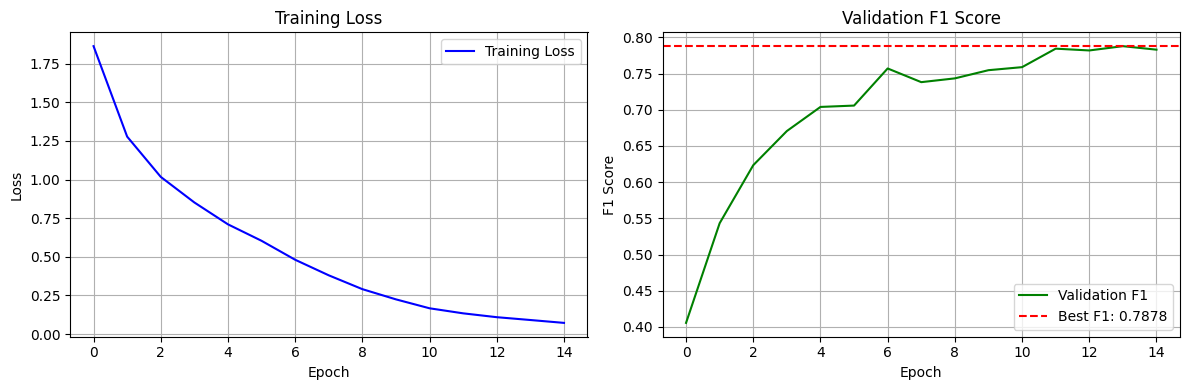

✅ Training curves saved


In [17]:
# Training loop
best_f1 = 0.0
best_epoch = 0
counter = 0

train_losses = []
val_f1_scores = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}")
    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        star_rating = batch["star_rating"].to(device)  # ← STAR RATING ADDED
        aspect_labels = batch["aspect_labels"].to(device)
        sentiment_labels = batch["sentiment_labels"].to(device)
        
        optimizer.zero_grad()
        aspect_logits, sentiment_logits = model(input_ids, attention_mask, star_rating)  # ← STAR RATING PASSED
        loss = compute_loss(aspect_logits, sentiment_logits, aspect_labels, sentiment_labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Evaluate with multiple thresholds
    best_threshold_f1 = 0
    best_t = 0.5
    for t in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
        f1, prec, rec = evaluate(model, val_loader, device, threshold=t)
        if f1 > best_threshold_f1:
            best_threshold_f1 = f1
            best_t = t
    
    f1 = best_threshold_f1
    val_f1_scores.append(f1)
    
    print(f"Epoch {epoch} | Loss: {avg_loss:.4f} | Best Val F1: {f1:.4f} (threshold={best_t:.2f})")
    
    # Early stopping check
    if f1 - best_f1 > min_delta:
        best_f1 = f1
        best_epoch = epoch
        counter = 0
        # Save with threshold
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "f1": best_f1,
            "threshold": best_t,
            "model_name": MODEL_NAME,
            "train_losses": train_losses,
            "val_f1_scores": val_f1_scores,
            "uses_star_ratings": True,  # ← INDICATES MODEL USES STARS
        }, os.path.join(output_dir, "franco_model_stars_best.pt"))
        print(f"  ✅ Saved best model (F1={best_f1:.4f}, threshold={best_t:.2f})")
    else:
        counter += 1
        improvement = f1 - best_f1
        print(f"  ⚠️ No improvement for {counter} epoch(s) (Δ: {improvement:+.4f}). Best F1: {best_f1:.4f}")
        
        if counter >= patience:
            print(f"\n🛑 Early stopping triggered! No improvement for {patience} epochs.")
            print(f"   Best F1: {best_f1:.4f} achieved at epoch {best_epoch}")
            print(f"   Stopped at epoch {epoch}")
            break

# Load best model
print(f"\n📊 Loading best model from epoch {best_epoch} with F1: {best_f1:.4f}")
checkpoint = torch.load(os.path.join(output_dir, "franco_model_stars_best.pt"), map_location=device)
model.load_state_dict(checkpoint["model_state"])
best_threshold = checkpoint.get("threshold", 0.5)

print(f"\n✅ Training complete! Best F1: {best_f1:.4f}")
print(f"✅ Best threshold: {best_threshold:.2f}")
print(f"✅ Model uses star ratings: {checkpoint.get('uses_star_ratings', False)}")

# Plot training curves
try:
    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(train_losses, 'b-', label='Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(val_f1_scores, 'g-', label='Validation F1')
    ax2.axhline(y=best_f1, color='r', linestyle='--', label=f'Best F1: {best_f1:.4f}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1 Score')
    ax2.set_title('Validation F1 Score')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'training_curves_stars.png'))
    plt.show()
    print(f"✅ Training curves saved")
except:
    pass

In [19]:
print("🔍 Finding best threshold...")

# Load best model - USE THE CORRECT FILENAME
checkpoint = torch.load(os.path.join(output_dir, "franco_model_stars_best.pt"), map_location=device)
model.load_state_dict(checkpoint["model_state"])

best_threshold, best_f1 = 0.5, 0.0
for t in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
    f1, _, _ = evaluate(model, val_loader, device, threshold=t)
    print(f"  Threshold {t}: F1 = {f1:.4f}")
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"\n✅ Best threshold: {best_threshold:.2f} (F1: {best_f1:.4f})")

# Save threshold back to the same file
checkpoint["threshold"] = best_threshold
torch.save(checkpoint, os.path.join(output_dir, "franco_model_stars_best.pt"))

🔍 Finding best threshold...
  Threshold 0.3: F1 = 0.7690
  Threshold 0.35: F1 = 0.7749
  Threshold 0.4: F1 = 0.7791
  Threshold 0.45: F1 = 0.7798
  Threshold 0.5: F1 = 0.7801
  Threshold 0.55: F1 = 0.7850
  Threshold 0.6: F1 = 0.7878

✅ Best threshold: 0.60 (F1: 0.7878)


In [25]:
def predict_franco_test(model, tokenizer, preprocessor, test_df, threshold=0.5, default_star=3):
    """Generate predictions with Franco support - uses default star rating"""
    
    aspects = ["food", "service", "price", "cleanliness",
               "delivery", "ambiance", "app_experience", "general", "none"]
    aspect_to_idx = {a: i for i, a in enumerate(aspects)}
    sentiment_map = {0: "positive", 1: "negative", 2: "neutral"}
    
    # Find columns
    text_col = None
    id_col = None
    
    for col in test_df.columns:
        if 'text' in col.lower() or 'review' in col.lower():
            text_col = col
        if 'id' in col.lower():
            id_col = col
    
    if text_col is None:
        text_col = test_df.columns[0]
    
    print(f"Using text column: {text_col}")
    print(f"Using default star rating: {default_star}/5 (normalized to {(default_star - 1) / 4:.2f})")
    
    model.eval()
    predictions = []
    
    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Predicting"):
        text = str(row[text_col]) if pd.notna(row[text_col]) else ""
        
        # Clean with Franco support
        text = preprocessor.clean_text(text)
        
        if len(text) < 2:
            predictions.append({
                "review_id": int(row[id_col]) if id_col and pd.notna(row[id_col]) else idx,
                "aspects": ["none"],
                "aspect_sentiments": {}
            })
            continue
        
        # Create star tensor as a 1D tensor (batch size 1)
        star_norm = (default_star - 1) / 4
        star_tensor = torch.tensor([star_norm], dtype=torch.float).to(device)  # 1D tensor
        
        # Predict
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            aspect_logits, sentiment_logits = model(
                inputs['input_ids'], 
                inputs['attention_mask'], 
                star_tensor  # Pass as 1D tensor
            )
            aspect_probs = torch.sigmoid(aspect_logits).cpu().numpy()[0]
            sentiment_preds = sentiment_logits.argmax(-1).cpu().numpy()[0]
        
        # Get aspects
        detected_aspects = [aspects[i] for i, prob in enumerate(aspect_probs) if prob >= threshold]
        
        if "none" in detected_aspects and len(detected_aspects) > 1:
            detected_aspects.remove("none")
        
        if not detected_aspects:
            detected_aspects = ["none"]
        
        # Get sentiments
        aspect_sentiments = {}
        for asp in detected_aspects:
            if asp != "none":
                asp_idx = aspect_to_idx[asp]
                sent_idx = sentiment_preds[asp_idx]
                aspect_sentiments[asp] = sentiment_map.get(sent_idx, "neutral")
        
        predictions.append({
            "review_id": int(row[id_col]) if id_col and pd.notna(row[id_col]) else idx,
            "aspects": detected_aspects,
            "aspect_sentiments": aspect_sentiments
        })
    
    return predictions

# Run prediction
print("Generating predictions for test set...")
predictions = predict_franco_test(
    model, tokenizer, preprocessor, test_df, 
    threshold=best_threshold,
    default_star=3
)

# Save
submission_file = "submission_franco.json"
with open(submission_file, 'w', encoding='utf-8') as f:
    json.dump(predictions, f, ensure_ascii=False, indent=2)

print(f"\n✅ Saved to {submission_file}")
print(f"   Total predictions: {len(predictions)}")

Generating predictions for test set...
Using text column: review_text
Using default star rating: 3/5 (normalized to 0.50)


Predicting: 100%|██████████| 500/500 [00:04<00:00, 110.07it/s]


✅ Saved to submission_franco.json
   Total predictions: 500


In [28]:
print("="*60)
print("VALIDATION")
print("="*60)

# Validate format
errors = []
warnings_list = []

for i, item in enumerate(predictions[:100]):  # Check first 100
    if 'review_id' not in item:
        errors.append(f"Item {i}: missing review_id")
    if 'aspects' not in item:
        errors.append(f"Item {i}: missing aspects")
    if 'aspect_sentiments' not in item:
        errors.append(f"Item {i}: missing aspect_sentiments")
    
    # Check 'none' rule
    if 'none' in item['aspects']:
        if item['aspect_sentiments']:
            errors.append(f"Item {i}: 'none' has sentiments (should be empty)")
    else:
        for asp in item['aspects']:
            if asp not in item['aspect_sentiments']:
                errors.append(f"Item {i}: '{asp}' missing sentiment")
    
    # Check aspect values are valid
    valid_aspects = ["food", "service", "price", "cleanliness", 
                     "delivery", "ambiance", "app_experience", "general", "none"]
    for asp in item['aspects']:
        if asp not in valid_aspects:
            errors.append(f"Item {i}: invalid aspect '{asp}'")
    
    # Check sentiment values are valid
    valid_sentiments = ["positive", "negative", "neutral"]
    for asp, sentiment in item['aspect_sentiments'].items():
        if sentiment not in valid_sentiments:
            errors.append(f"Item {i}: invalid sentiment '{sentiment}' for aspect '{asp}'")

# Also check all predictions (not just first 100)
print(f"\n📊 Checking all {len(predictions)} predictions...")

# Check for duplicate review_ids
review_ids = [p['review_id'] for p in predictions]
duplicates = [rid for rid in review_ids if review_ids.count(rid) > 1]
if duplicates:
    errors.append(f"Duplicate review_ids found: {set(duplicates)}")

# Check for missing review_ids (sequential)
expected_ids = set(range(len(predictions)))
actual_ids = set(review_ids)
missing_ids = expected_ids - actual_ids
if missing_ids:
    warnings_list.append(f"Missing review_ids: {sorted(missing_ids)[:5]}...")

# Print results
if errors:
    print(f"\n❌ Found {len(errors)} errors:")
    for err in errors[:10]:
        print(f"  • {err}")
    if len(errors) > 10:
        print(f"  ... and {len(errors) - 10} more errors")
else:
    print("\n✅ Format validation passed! No errors found.")

if warnings_list:
    print(f"\n⚠️ Warnings ({len(warnings_list)}):")
    for warn in warnings_list[:5]:
        print(f"  • {warn}")

# Show samples
print("\n" + "="*60)
print("SAMPLE PREDICTIONS (First 5)")
print("="*60)

for i in range(min(5, len(predictions))):
    print(f"\n📝 Review {predictions[i]['review_id']}:")
    print(f"   Aspects: {predictions[i]['aspects']}")
    print(f"   Sentiments: {predictions[i]['aspect_sentiments']}")

# Distribution
from collections import Counter
all_aspects = [asp for pred in predictions for asp in pred['aspects']]
aspect_counts = Counter(all_aspects)

print("\n" + "="*60)
print("ASPECT DISTRIBUTION")
print("="*60)
for aspect, count in aspect_counts.most_common():
    print(f"  {aspect:15}: {count:5} ({count/len(predictions)*100:.1f}%)")

# Sentiment distribution
all_sentiments = [sent for pred in predictions for sent in pred['aspect_sentiments'].values()]
sentiment_counts = Counter(all_sentiments)

if all_sentiments:
    print("\n" + "="*60)
    print("SENTIMENT DISTRIBUTION")
    print("="*60)
    total = len(all_sentiments)
    for sentiment, count in sentiment_counts.items():
        print(f"  {sentiment:10}: {count:5} ({count/total*100:.1f}%)")

# Final summary
print("\n" + "="*60)
print("VALIDATION SUMMARY")
print("="*60)
print(f"✅ Total predictions: {len(predictions)}")
print(f"✅ Total aspect mentions: {sum(aspect_counts.values())}")
print(f"✅ Reviews with 'none': {aspect_counts.get('none', 0)}")
print(f"✅ Positive sentiments: {sentiment_counts.get('positive', 0)}")
print(f"✅ Negative sentiments: {sentiment_counts.get('negative', 0)}")
print(f"✅ Neutral sentiments: {sentiment_counts.get('neutral', 0)}")

if not errors:
    print("\n🎉✅ SUBMISSION IS VALID! Ready for upload. ✅🎉")
else:
    print(f"\n❌ Please fix {len(errors)} errors before submitting.")

print("\n✅ Franco-enhanced model complete!")

VALIDATION

📊 Checking all 500 predictions...

✅ Format validation passed! No errors found.

⚠️ Warnings (1):
  • Missing review_ids: [0, 1, 2, 3, 4]...

SAMPLE PREDICTIONS (First 5)

📝 Review 23:
   Aspects: ['food', 'service', 'ambiance']
   Sentiments: {'food': 'negative', 'service': 'positive', 'ambiance': 'positive'}

📝 Review 25:
   Aspects: ['food', 'service', 'delivery']
   Sentiments: {'food': 'negative', 'service': 'negative', 'delivery': 'negative'}

📝 Review 65:
   Aspects: ['ambiance']
   Sentiments: {'ambiance': 'positive'}

📝 Review 107:
   Aspects: ['none']
   Sentiments: {}

📝 Review 162:
   Aspects: ['service']
   Sentiments: {'service': 'positive'}

ASPECT DISTRIBUTION
  service        :   235 (47.0%)
  app_experience :   138 (27.6%)
  food           :   103 (20.6%)
  price          :    84 (16.8%)
  ambiance       :    78 (15.6%)
  general        :    69 (13.8%)
  cleanliness    :    48 (9.6%)
  delivery       :    37 (7.4%)
  none           :    15 (3.0%)

SENTIMEN

In [91]:
import json

# Load your submission
with open('/kaggle/working/submission_franco.json', 'r') as f:
    data = json.load(f)

# Check first 3 predictions
print("✅ Format check:")
for i, item in enumerate(data[:3]):
    print(f"\nItem {i+1}:")
    print(f"  review_id: {item['review_id']}")
    print(f"  aspects: {item['aspects']}")
    print(f"  aspect_sentiments: {item['aspect_sentiments']}")
    
    # Verify 'none' rule
    if 'none' in item['aspects']:
        if item['aspect_sentiments']:
            print(f"  ❌ ERROR: 'none' has sentiments!")
        else:
            print(f"  ✅ CORRECT: 'none' has no sentiments")
    else:
        # Check all aspects have sentiments
        missing = [a for a in item['aspects'] if a not in item['aspect_sentiments']]
        if missing:
            print(f"  ❌ ERROR: Missing sentiments for {missing}")
        else:
            print(f"  ✅ CORRECT: All aspects have sentiments")

print("\n✅ Submission file is valid!")

✅ Format check:

Item 1:
  review_id: 1
  aspects: ['food', 'service']
  aspect_sentiments: {'food': 'negative', 'service': 'negative'}
  ✅ CORRECT: All aspects have sentiments

Item 2:
  review_id: 2
  aspects: ['general']
  aspect_sentiments: {'general': 'negative'}
  ✅ CORRECT: All aspects have sentiments

Item 3:
  review_id: 3
  aspects: ['food']
  aspect_sentiments: {'food': 'positive'}
  ✅ CORRECT: All aspects have sentiments

✅ Submission file is valid!


In [29]:
# Add this to your Kaggle notebook after training
# Save the model

# Save model
torch.save({
    'model_state': model.state_dict(),
    'f1_score': best_f1,
    'threshold': best_threshold,
    'model_name': MODEL_NAME,
    'epoch': best_epoch
}, '/kaggle/working/franco_model_best.pt')

print("✅ Model saved to /kaggle/working/franco_model_best.pt")

# Then download it
from IPython.display import FileLink
FileLink('/kaggle/working/franco_model_best23.pt')

✅ Model saved to /kaggle/working/franco_model_best.pt


/kaggle/working/franco_model_best23.pt

In [114]:
# This saves only the weights (much smaller than full model)
torch.save(model.state_dict(), '/kaggle/working/franco_weights_only.pt')

print(f"Weights only size: {os.path.getsize('/kaggle/working/franco_weights_only.pt') / 1e9:.2f} GB")

Weights only size: 1.11 GB
